<a href="https://colab.research.google.com/github/sgruyzcki/DiploDatos2026/blob/main/Aprendizaje%20No%20Supervisado/Practico%201/ANS_2026_Entregable_Mariano.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **Diplomatura en Ciencia de Datos, Aprendizaje Automático y sus Aplicaciones**

## **Edición 2026**

---
## Entregable

### Consignas


#### 1. Análisis exploratorio inicial de la base.

Se espera que el análisis incluya, como mínimo:

* **Dimensiones** de la base (cantidad de filas y columnas) y **tipos de variables** presentes (numéricas, categóricas, identificadores, etc.).

* Identificación de las **columnas relevantes** para el objetivo del trabajo (encontrar grupos de jugadores con habilidades equivalentes), descartando desde el inicio aquellas que claramente no aportan (identificadores, URLs de imágenes, etc.). **Justificación explícita** de qué variables se conservan y cuáles se descartan para las etapas siguientes del trabajo, explicando el criterio utilizado (relevancia para el objetivo, redundancia con otras variables, calidad de los datos, etc.).

* Detección y tratamiento de valores faltantes (¿qué variables tienen missing values, en qué proporción, y qué se decidió hacer: imputar, descartar filas/columnas, etc.?) y de posibles duplicados.

* Estadística descriptiva de las variables numéricas relevantes (medidas de tendencia central y dispersión), señalando casos llamativos (rangos inesperados, asimetrías fuertes, outliers evidentes).

* Distribución de las principales variables categóricas: posición, liga y nacionalidad, entre otras que el grupo considere relevantes, con al menos una visualización por variable.

#### 2. Evaluación visual e intuitiva de dos a dos variables numéricas por vez.

Sugerencia: hagan los scatterplots de las combinaciones de dos variables que tengan algún sentido para ustedes, porque todas las combinaciones de variables son muchas y no van a poder analizarlas como merecen.

#### 3. Pregunta: ¿Se realizó alguna normalización o escalado de la base? ¿Por qué?

#### 4. Aplicación de clustering para encontrar grupos de jugadores con habilidades equivalentes

Por ejemplo, jugadores que podrían intercambiarse en el caso de una lesión o cuando un jugador está cansado. Para esto utilice como mínimo dos técnicas de clustering: por ejemplo k-medias,MinShift, DBSCAN, mezcla de Gaussianas y/o Single linkage y otras jerárquicas. Justifiquen por qué eligen los diferentes hiper-parámetros que se puedan elegir según el método: número de clusters, medida de distancia, criterio de aglomeración… Utilicen al menos una métrica cuantitativa de evaluación de clustering (por ejemplo, coeficiente de silhouette, índice de rand ajustado, u otra que consideren pertinente) para comparar los resultados obtenidos con las distintas técnicas y/o configuraciones de hiperparámetros probadas, y justifiquen a partir de esas métricas cuál configuración/método les resultó más adecuado.

#### 5. Análisis cualitativo de los clusters encontrados.

¿Qué hay en cada cluster? ¿Son efectivamente equivalentes los jugadores de un cluster, es decir, podrían cumplir el mismo rol en un equipo? Si se trata de clusters heterogéneos, ¿por qué razón pueden haber sido agrupadas las jugadoras del cluster? ¿Qué motiva las diferencias en tamaño?

#### 6. Uso de alguna transformación (proyección, Embedding) para visualizar los resultados y/o usarla como preprocesado para aplicar alguna técnica de clustering.

#### 7. Comparación de interpretaciones humano vs. LLMs sobre el análisis de clusters

Para reflexionar críticamente sobre el rol del conocimiento experto/de dominio frente a la interpretación automática de resultados de clustering, y sobre las capacidades y limitaciones actuales de los modelos de lenguaje para el análisis de datos.

a) Tomar los resultados del punto 5 (caracterización de clusters ya realizada por el grupo) y presentarle a Claude, ChatGPT y Gemini exactamente la misma información: por ejemplo, tabla de centroides/estadísticos descriptivos por cluster, tamaño de cada cluster, y las variables utilizadas para clusterizar (sin incluir la interpretación propia del grupo, para no sesgar al modelo).

b) Pedirle a cada uno de los tres modelos, con el mismo prompt, que interprete los clusters: qué representa cada uno, si los jugadores dentro de un cluster son "equivalentes", y qué podría explicar la heterogeneidad o el tamaño de los grupos.

c) Documentar textualmente (o via capturas) las tres respuestas obtenidas.

d) Realizar un análisis comparativo entre las tres respuestas y la interpretación propia del grupo (la del punto 5), atendiendo especialmente a:

Coincidencias y diferencias entre los tres modelos.

Casos en que algún modelo haya "alucinado" datos, sacado conclusiones no sustentadas por los números, o generalizado de forma poco rigurosa.

Casos en que el grupo, gracias a conocimiento de dominio (reglas del fútbol, entendimiento de posiciones, lógica de mercado de pases, conocimiento de jugadores reales, contexto de la temporada/base de datos, etc.), pudo identificar matices, errores o explicaciones que ningún modelo mencionó.

Información contextual que un experto humano valora naturalmente pero que los modelos no tienen forma de inferir sólo de números (ej.: un jugador lesionado en el momento del snapshot de datos, un jugador joven con potencial subestimado por las métricas actuales, diferencias entre ligas de distinto nivel competitivo que igualan estadísticas de forma engañosa, etc.).

Diferencias en el "tono" de certeza: ¿los modelos matizan sus afirmaciones o presentan interpretaciones especulativas como si fueran hechos?

e) Conclusión breve reflexionando sobre: ¿en qué tareas de este análisis un LLM aporta valor real (por ejemplo, generación rápida de hipótesis, redacción, resumen)? ¿En qué tareas resulta insuficiente o directamente engañoso sin supervisión experta? ¿Qué rol debería tener, en la práctica profesional de un/a científico/a de datos, el uso de estas herramientas para interpretar resultados de un análisis no supervisado?

### 0. Carga del dataset

In [ ]:
# Actualizar modificaciones de archivos utils.py sin interrumpit el kernel
%load_ext autoreload
%autoreload 2

In [ ]:
# Librerias nativas
import os
import re
import sys
import datetime
import itertools
import warnings
import io
import math
warnings.filterwarnings("ignore")

# Librerias externas
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import seaborn as sns
import missingno as msno
import plotly.graph_objs as go
import plotly.tools as tls #visualization
import plotly.figure_factory as ff #visualization
from pathlib import Path
from plotly.offline import init_notebook_mode, plot,iplot

import pandas as pd
from IPython.display import Markdown, display

# Desactivar límites de visualización de filas y columnas
pd.set_option('display.max_columns',110)
pd.set_option('display.max_rows',1000)
pd.set_option('display.max_colwidth', None)

sns.set_context('talk')

init_notebook_mode(connected=True)

| Variable | Descripción | Tipo |
| --- | --- | --- |
| `player_id` | player id on sofifa | id |
| `player_url`| url of the scraped player | url |
| `fifa_version` | fifa version of team's data (from 15 to 24) | id |
| `fifa_update` | fifa update number of team's data |
| `update_as_of` | fifa date of update of team's data |
| `short_name` | player short name |
| `long_name` | player long name |
| `player_positions` | player preferred positions |
| `overall` | player current overall attribute | num |
| `potential` | player potential overall attribute  num |
| `value_eur` | player value (in eur) | num |
| `wage_eur` | player weekly wage (in eur) | num |
| `age` | player age | num |
| `dob` | player date of birth |
| `height_cm` | player height (in cm) | num |
| `weight_kg` | player weight (in kg) | num |
| `club_team_id` | club team_id where the player plays | id |
| `club_name` | club name where the player plays |
| `league_id` | league id where the team played in that fifa version | id |
| `league_name` | league name where the player played in that specific fifa version and update |
| `league_level` | level of the league where the player played in that fifa version |
| `club_position` | player position in the club (e.g. sub means substitute, res means reserve) |
| `club_jersey_number` | player jersey number in the club | num |
| `club_loaned_from` | club loaning out the player - if applicable |
| `club_joined_date` | date when the player joined his current club |
| `club_contract_valid_until_year` | player contract expiration date |
| `nationality_id` | player nationality id | id |
| `nationality_name` | player nationality name |
| `nation_team_id` | national team_id where the player plays | id |
| `nation_position` | player position in the national team | num |
| `nation_jersey_number` | player jersey number in the national team |
| `preferred_foot` | player preferred foot |
| `weak_foot` | player weak foot attribute |
| `skill_moves` | player skill moves attribute | num |
| `international_reputation` | player international reputation attribute |
| `work_rate` | player work rate attributes (attacking / defensive) |
| `body_type` | player body type |
| `real_face` | player real face |
| `release_clause_eur` | player release clause (in eur) - if applicable |
| `player_tags` | player tags |
| `player_traits` | player traits |
| `pace` | player pace attribute | num |
| `shooting` | player shooting attribute | num |
| `passing` | player passing attribute | num |
| `dribbling` | player dribbling attribute | num |
| `defending` | player defending attribute | num |
| `physic` | player physic attribute | num |
| `attacking_crossing` | player crossing attribute | num |
| `attacking_finishing` | player finishing attribute | num |
| `attacking_heading_accuracy` | player heading accuracy attribute | num |
| `attacking_short_passing` | player short passing attribute | num |
| `attacking_volleys` | player volleys attribute | num |
| `skill_dribbling` | player dribbling attribute | num |
| `skill_curve` | player curve attribute | num |
| `skill_fk_accuracy` | player free-kick accuracy attribute | num |
| `skill_long_passing` | player long passing attribute | num |
| `skill_ball_control` | player ball control attribute | num |
| `movement_acceleration` | player acceleration attribute | num |
| `movement_sprint_speed` | player sprint speed attribute | num |
| `movement_agility` | player agility attribute | num |
| `movement_reactions` | player reactions attribute | num |
| `movement_balance` | player balance attribute | num |
| `power_shot_power` | player shot power attribute | num |
| `power_jumping` | player jumping attribute | num |
| `power_stamina` | player stamina attribute | num |
| `power_strength` | player strength attribute | num |
| `power_long_shots` | player long shots attribute | num |
| `mentality_aggression`| player aggression attribute| num |
| `mentality_interceptions`| player interceptions attribute| num |
| `mentality_positioning`| player positioning attribute| num |
| `mentality_vision`| player vision attribute| num |
| `mentality_penalties`| player penalties attribute| num |
| `mentality_composure`| player composure attribute| num |
| `defending_marking_awareness`| player marking awareness attribute| num |
| `defending_standing_tackle`| player standing tackle attribute| num |
| `defending_sliding_tackle`| player sliding tackle attribute| num |
| `defending_sliding_tackle`| player gk diving attribute| num |
| `goalkeeping_handling`| player gk handling attribute| num |
| `goalkeeping_diving`| player gk diving attribute| num |
| `goalkeeping_kicking`| player gk kicking attribute| num |
| `goalkeeping_positioning`| player gk positioning attribute| num |
| `goalkeeping_reflexes`| player gk reflexes attribute| num |
| `goalkeeping_speed`| player gk speed attribute| num |
| `ls` | player attribute playing as ls|
| `st` | player attribute playing as st|
| `rs` | player attribute playing as rs|
| `lw` | player attribute playing as lw |
| `lf` | player attribute playing as lf|
| `cf` | player attribute playing as cf|
| `rf` | player attribute playing as rf|
| `rw` |player attribute playing as rw|
| `lam` | player attribute playing as lam|
| `cam` |player attribute playing as cam|
| `ram` |player attribute playing as ram|
| `lm`|player attribute playing as lm|
| `lcm`| player attribute playing as lcm|
| `cm`| player attribute playing as cm|
| `rcm`| player attribute playing as rcm|
| `rm`| player attribute playing as rm|
| `lwb`| player attribute playing as lwb|
| `ldm`| player attribute playing as ldm|
| `cdm`| player attribute playing as cdm|
| `rdm`| player attribute playing as rdm|
| `rwb`| player attribute playing as rwb|
| `lb`| player attribute playing as lb|
| `lcb`| player attribute playing as lcb|
| `cb`| player attribute playing as cb|
| `rcb`| player attribute playing as rcb|
| `rb`| player attribute playing as rb|
| `gk`| player attribute playing as gk|

In [ ]:
# Añade el directorio raíz del proyecto
root_path = Path.cwd().parent
if str(root_path) not in sys.path:
    sys.path.insert(0, str(root_path))

In [ ]:
# Ruta raíz del proyecto
root_path = Path().resolve()

# Diccionario PATHS con objetos Path
PATHS = {
    "raw": root_path / "data" / "male_players.csv"
}

In [ ]:
df = pd.read_csv(PATHS["raw"],encoding="utf-8", low_memory=False)
data_raw = df.copy()
data_raw.head(5)

,player_id,player_url,fifa_version,fifa_update,update_as_of,short_name,long_name,player_positions,overall,potential,value_eur,wage_eur,age,dob,height_cm,weight_kg,club_team_id,club_name,league_id,league_name,league_level,club_position,club_jersey_number,club_loaned_from,club_joined_date,club_contract_valid_until_year,nationality_id,nationality_name,nation_team_id,nation_position,nation_jersey_number,preferred_foot,weak_foot,skill_moves,international_reputation,work_rate,body_type,real_face,release_clause_eur,player_tags,player_traits,pace,shooting,passing,dribbling,defending,physic,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_short_passing,attacking_volleys,skill_dribbling,skill_curve,skill_fk_accuracy,skill_long_passing,skill_ball_control,movement_acceleration,movement_sprint_speed,movement_agility,movement_reactions,movement_balance,power_shot_power,power_jumping,power_stamina,power_strength,power_long_shots,mentality_aggression,mentality_interceptions,mentality_positioning,mentality_vision,mentality_penalties,mentality_composure,defending_marking_awareness,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,goalkeeping_speed,ls,st,rs,lw,lf,cf,rf,rw,lam,cam,ram,lm,lcm,cm,rcm,rm,lwb,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb,gk
0,231747,/player/231747/kylian-mbappe/240002,24.0,2.0,2023-09-22,K. Mbappé,Kylian Mbappé Lottin,"ST, LW",91,94,181500000.0,230000.0,24,1998-12-20,182,75,73.0,Paris Saint Germain,16.0,Ligue 1,1.0,LW,7.0,NaN,2018-07-01,2024.0,18,France,1335.0,LW,10.0,Right,4,5,5,High/Low,Unique,Yes,349400000.0,"#Speedster, #Dribbler, #Acrobat, #Clinical finisher, #Complete forward","Quick Step +, Rapid, Flair, Trivela",97.0,90.0,80.0,92.0,36.0,78.0,78,94,73,86,84,93,80,69,71,92,97,97,93,93,82,90,88,88,77,83,64,38,93,83,84,88.0,26,34,32,13,5,7,11,6,NaN,90+3,90+3,90+3,91,91,91,91,91,89+3,89+3,89+3,89+3,81+3,81+3,81+3,89+3,68+3,63+3,63+3,63+3,68+3,63+3,54+3,54+3,54+3,63+3,18+3
1,239085,/player/239085/erling-haaland/240002,24.0,2.0,2023-09-22,E. Haaland,Erling Braut Haaland,ST,91,94,185000000.0,340000.0,22,2000-07-21,195,94,10.0,Manchester City,13.0,Premier League,1.0,ST,9.0,NaN,2022-07-01,2027.0,36,Norway,1352.0,ST,9.0,Left,3,3,5,High/Medium,Unique,Yes,356100000.0,"#Aerial threat, #Distance shooter, #Strength, #Clinical finisher, #Complete forward","Acrobatic +, Power Header, Quick Step",89.0,93.0,66.0,80.0,45.0,88.0,47,96,83,77,90,79,77,62,53,82,82,94,76,94,72,94,93,76,93,86,87,43,96,74,84,87.0,38,47,29,7,14,13,11,7,NaN,90+3,90+3,90+3,82,86,86,86,82,82+3,82+3,82+3,79+3,74+3,74+3,74+3,79+3,62+3,63+3,63+3,63+3,62+3,60+3,62+3,62+3,62+3,60+3,19+3
2,192985,/player/192985/kevin-de-bruyne/240002,24.0,2.0,2023-09-22,K. De Bruyne,Kevin De Bruyne,"CM, CAM",91,91,103000000.0,350000.0,32,1991-06-28,181,75,10.0,Manchester City,13.0,Premier League,1.0,SUB,17.0,NaN,2015-08-30,2025.0,7,Belgium,1325.0,CAM,7.0,Right,5,4,5,High/Medium,Unique,Yes,190600000.0,"#Dribbler, #Playmaker, #Distance shooter, #Crosser, #Complete midfielder","Pinged Pass +, Dead Ball, Incisive Pass, Long Ball Pass, Whipped Cross, Trivela",72.0,88.0,94.0,87.0,65.0,78.0,95,85,55,94,83,86,92,83,94,92,72,72,74,92,78,92,72,88,74,92,75,66,88,95,83,88.0,66,70,53,15,13,5,10,13,NaN,83+3,83+3,83+3,87,88,88,88,87,89+2,89+2,89+2,88+3,90+1,90+1,90+1,88+3,79+3,80+3,80+3,80+3,79+3,75+3,70+3,70+3,70+3,75+3,21+3
3,158023,/player/158023/lionel-messi/240002,24.0,2.0,2023-09-22,L. Messi,Lionel Andrés Messi Cuccittini,"CF, CAM",90,90,41000000.0,23000.0,36,1987-06-24,169,67,112893.0,Inter Miami,39.0,Major League Soccer,1.0,RF,10.0,NaN,2023-07-16,2025.0,52,Argentina,1369.0,RW,10.0,Left,4,4,5,Low/Low,Unique,Yes,61500000.0,"#Dribbler, #Playmaker, #FK Specialist, #Acrobat, #Clinical finisher, #Complete midfielder, #Complete forward","Technical +, Finesse Shot, Dead Ball, Pinged Pass, Tiki Taka, Quick Step, Trivela",80.0,87.0,90.0,94.0,33.0,64.0,83,89,60,91,86,96,93,93,90,

In [ ]:
data_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 180021 entries, 0 to 180020
Columns: 109 entries, player_id to gk
dtypes: float64(20), int64(43), str(46)
memory usage: 149.7 MB


Vemos que el dataset tiene una dimensión muy alta, pues posee 109 columnas y 180k filas. Debemos implementar otras técnicas para estudiar su contenido:
Lo primero que haremos será crear una tabla de metadatos para ver algunas características generales del dataset.

In [ ]:
resumen = pd.DataFrame(
    {
        'Tipo': data_raw.dtypes,
        'No Nulos': data_raw.notna().sum(),
        'Nulos': data_raw.isnull().sum(),
        '% Nulos': (data_raw.isnull().sum() / len(df) * 100).round(2),
        'Únicos': data_raw.nunique(),
        'Ejemplo': data_raw.iloc[0],  # Muestra el primer registro como muestra
    }
)

# Ahora puedes filtrar esta tabla libremente:
display(resumen)

# Ejemplo: Ver solo las columnas con nulos ordenadas de mayor a menor
# resumen[resumen['Nulos'] > 0].sort_values(by='% Nulos', ascending=False)

,Tipo,No Nulos,Nulos,% Nulos,Únicos,Ejemplo
player_id,int64,180021,0,0.00,53111,231747
player_url,str,180021,0,0.00,180021,/player/231747/kylian-mbappe/240002
fifa_version,float64,180021,0,0.00,10,24.0
fifa_update,float64,180021,0,0.00,1,2.0
update_as_of,str,180021,0,0.00,10,2023-09-22
short_name,str,180021,0,0.00,47272,K. Mbappé
long_name,str,180021,0,0.00,52892,Kylian Mbappé Lottin
player_positions,str,180021,0,0.00,2031,"ST, LW"
overall,int64,180021,0,0.00,55,91
potential,int64,180021,0,0.00,54,94


In [ ]:
resumen[resumen['Nulos'] > 0].sort_values(by='% Nulos', ascending=False)

,Tipo,No Nulos,Nulos,% Nulos,Únicos,Ejemplo
nation_position,str,10098,169923,94.39,29,LW
nation_jersey_number,float64,10098,169923,94.39,34,10.0
nation_team_id,float64,10098,169923,94.39,56,1335.0
club_loaned_from,str,10723,169298,94.04,831,NaN
player_tags,str,13918,166103,92.27,204,"#Speedster, #Dribbler, #Acrobat, #Clinical finisher, #Complete forward"
goalkeeping_speed,float64,20024,159997,88.88,57,NaN
player_traits,str,81805,98216,54.56,5208,"Quick Step +, Rapid, Flair, Trivela"
release_clause_eur,float64,120722,59299,32.94,1919,349400000.0
mentality_composure,float64,147133,32888,18.27,88,88.0
physic,float64,159997,20024,11.12,66,78.0


### 1. Limpieza

In [ ]:
# Conservamos las entradas correspondientes a versiones de fifa posteriores a 2017
data_raw = data_raw[data_raw['fifa_version'] >= 17]

In [ ]:
# Columnas a descartar
useless_cols = ['player_id', 'player_url', 'fifa_version', 'fifa_update', 'update_as_of', 'long_name', 'value_eur',
               'wage_eur', 'dob', 'club_team_id', 'club_name', 'league_id', 'league_name', 'league_level', 'club_position',
               'club_jersey_number', 'club_loaned_from', 'club_joined_date', 'club_contract_valid_until_year', 'nationality_id',
               'nation_team_id', 'nation_jersey_number', 'international_reputation', 'real_face', 'release_clause_eur', 'player_tags',
               'player_traits','nation_position','pace','defending','physic','dribbling','passing','shooting']

In [ ]:
# Se eliminan columnas duplicadas
data_filtered = data_raw.drop_duplicates().copy()

# Se eliminan columnas vacías generadas por separadores sobrantes al final de cada fila
data_filtered = data_filtered.drop(columns=useless_cols)
print(f"Filas: {data_filtered.shape[0]:,} | Columnas: {data_filtered.shape[1]}")

Filas: 147,133 | Columnas: 75


In [ ]:
clean_resume = pd.DataFrame(
    {
        'Tipo': data_filtered.dtypes,
        'No Nulos': data_filtered.notna().sum(),
        'Nulos': data_filtered.isnull().sum(),
        '% Nulos': (data_filtered.isnull().sum() / len(df) * 100).round(2),
        'Únicos': data_filtered.nunique(),
        'Ejemplo': data_filtered.iloc[0],  # Muestra el primer registro como muestra
    }
)

# Ahora puedes filtrar esta tabla libremente:
display(clean_resume.sort_values(by='% Nulos', ascending=False))

,Tipo,No Nulos,Nulos,% Nulos,Únicos,Ejemplo
goalkeeping_speed,float64,16421,130712,72.61,57,NaN
lam,str,147133,0,0.00,378,89+3
rf,str,147133,0,0.00,275,91
cf,str,147133,0,0.00,275,91
lf,str,147133,0,0.00,275,91
lw,str,147133,0,0.00,295,91
rs,str,147133,0,0.00,348,90+3
st,str,147133,0,0.00,348,90+3
ls,str,147133,0,0.00,348,90+3
short_name,str,147133,0,0.00,42086,K. Mbappé


Vemos que de las columnas conservadas, solo dos tienen valores nulos presentes. El 72.61% de valores nulos en goalkeeping_speed indican que la categoría no corresponde a la mayoría de los jugadores registrados, pues es una característica exclusiva de los arqueros (gk). Podría imputarse con 0 para asignarle un valor del rango continuo [0,100], pero esto tendría repercusiones negativas sobre el algoritmo de clustering:

1. Sesgo por valor dominante: Más del 90% del dataset tendrá un valor de 0 exacto en esa variable.

2. Efecto en el escalado: Al aplicar StandardScaler o MinMaxScaler, la gran cantidad de ceros distorsionará la varianza. El algoritmo usará las características de goalkeeping principalmente para "aislar" a los arqueros, restándole peso a las diferencias sutiles entre delanteros, mediocampistas y defensas.

Se opta por eliminar este feature de la lista de skills para hacer el clustering, a fin de lograr un mejor resultado en la clasificacion de jugadores de campo

In [ ]:
skills = ['attacking_crossing','attacking_finishing',
          'attacking_heading_accuracy','attacking_short_passing','attacking_volleys','skill_dribbling', 'skill_curve',
          'skill_fk_accuracy','skill_long_passing','skill_ball_control','movement_acceleration','movement_sprint_speed',
          'movement_agility','movement_reactions','movement_balance','power_shot_power','power_jumping','power_stamina',
          'power_strength','power_long_shots','mentality_aggression','mentality_interceptions','mentality_positioning',
          'mentality_vision','mentality_penalties','mentality_composure','defending_marking_awareness','defending_standing_tackle',
          'defending_sliding_tackle','goalkeeping_handling','goalkeeping_diving','goalkeeping_kicking','goalkeeping_positioning',
          'goalkeeping_reflexes']

forwards=['RF','ST','LW','LF','RS','LS','RW','CF']
midfielders=['RCM','LCM','LDM','CAM','CDM','LAM','RDM','CM','RAM','RM','LM']
defenders=['RCB','CB','LCB','LB','RB','RWB','LWB']
goalkeepers=['GK']

In [ ]:
df_skills = data_filtered[skills].copy()

In [ ]:
df_skills.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
attacking_crossing,147133.0,49.58,18.19,5.0,38.0,54.0,63.0,95.0
attacking_finishing,147133.0,45.70,19.58,2.0,30.0,49.0,62.0,96.0
attacking_heading_accuracy,147133.0,52.03,17.37,4.0,44.0,55.0,64.0,94.0
attacking_short_passing,147133.0,58.65,14.64,7.0,54.0,62.0,68.0,94.0
attacking_volleys,147133.0,42.77,17.67,3.0,30.0,44.0,56.0,93.0
skill_dribbling,147133.0,55.44,18.85,2.0,49.0,61.0,68.0,97.0
skill_curve,147133.0,47.32,18.24,4.0,35.0,49.0,61.0,94.0
skill_fk_accuracy,147133.0,42.79,17.30,3.0,31.0,42.0,56.0,94.0
skill_long_passing,147133.0,52.87,15.16,5.0,43.0,56.0,64.0,94.0
skill_ball_control,147133.0,58.34,16.71,5.0,54.0,63.0,69.0,96.0


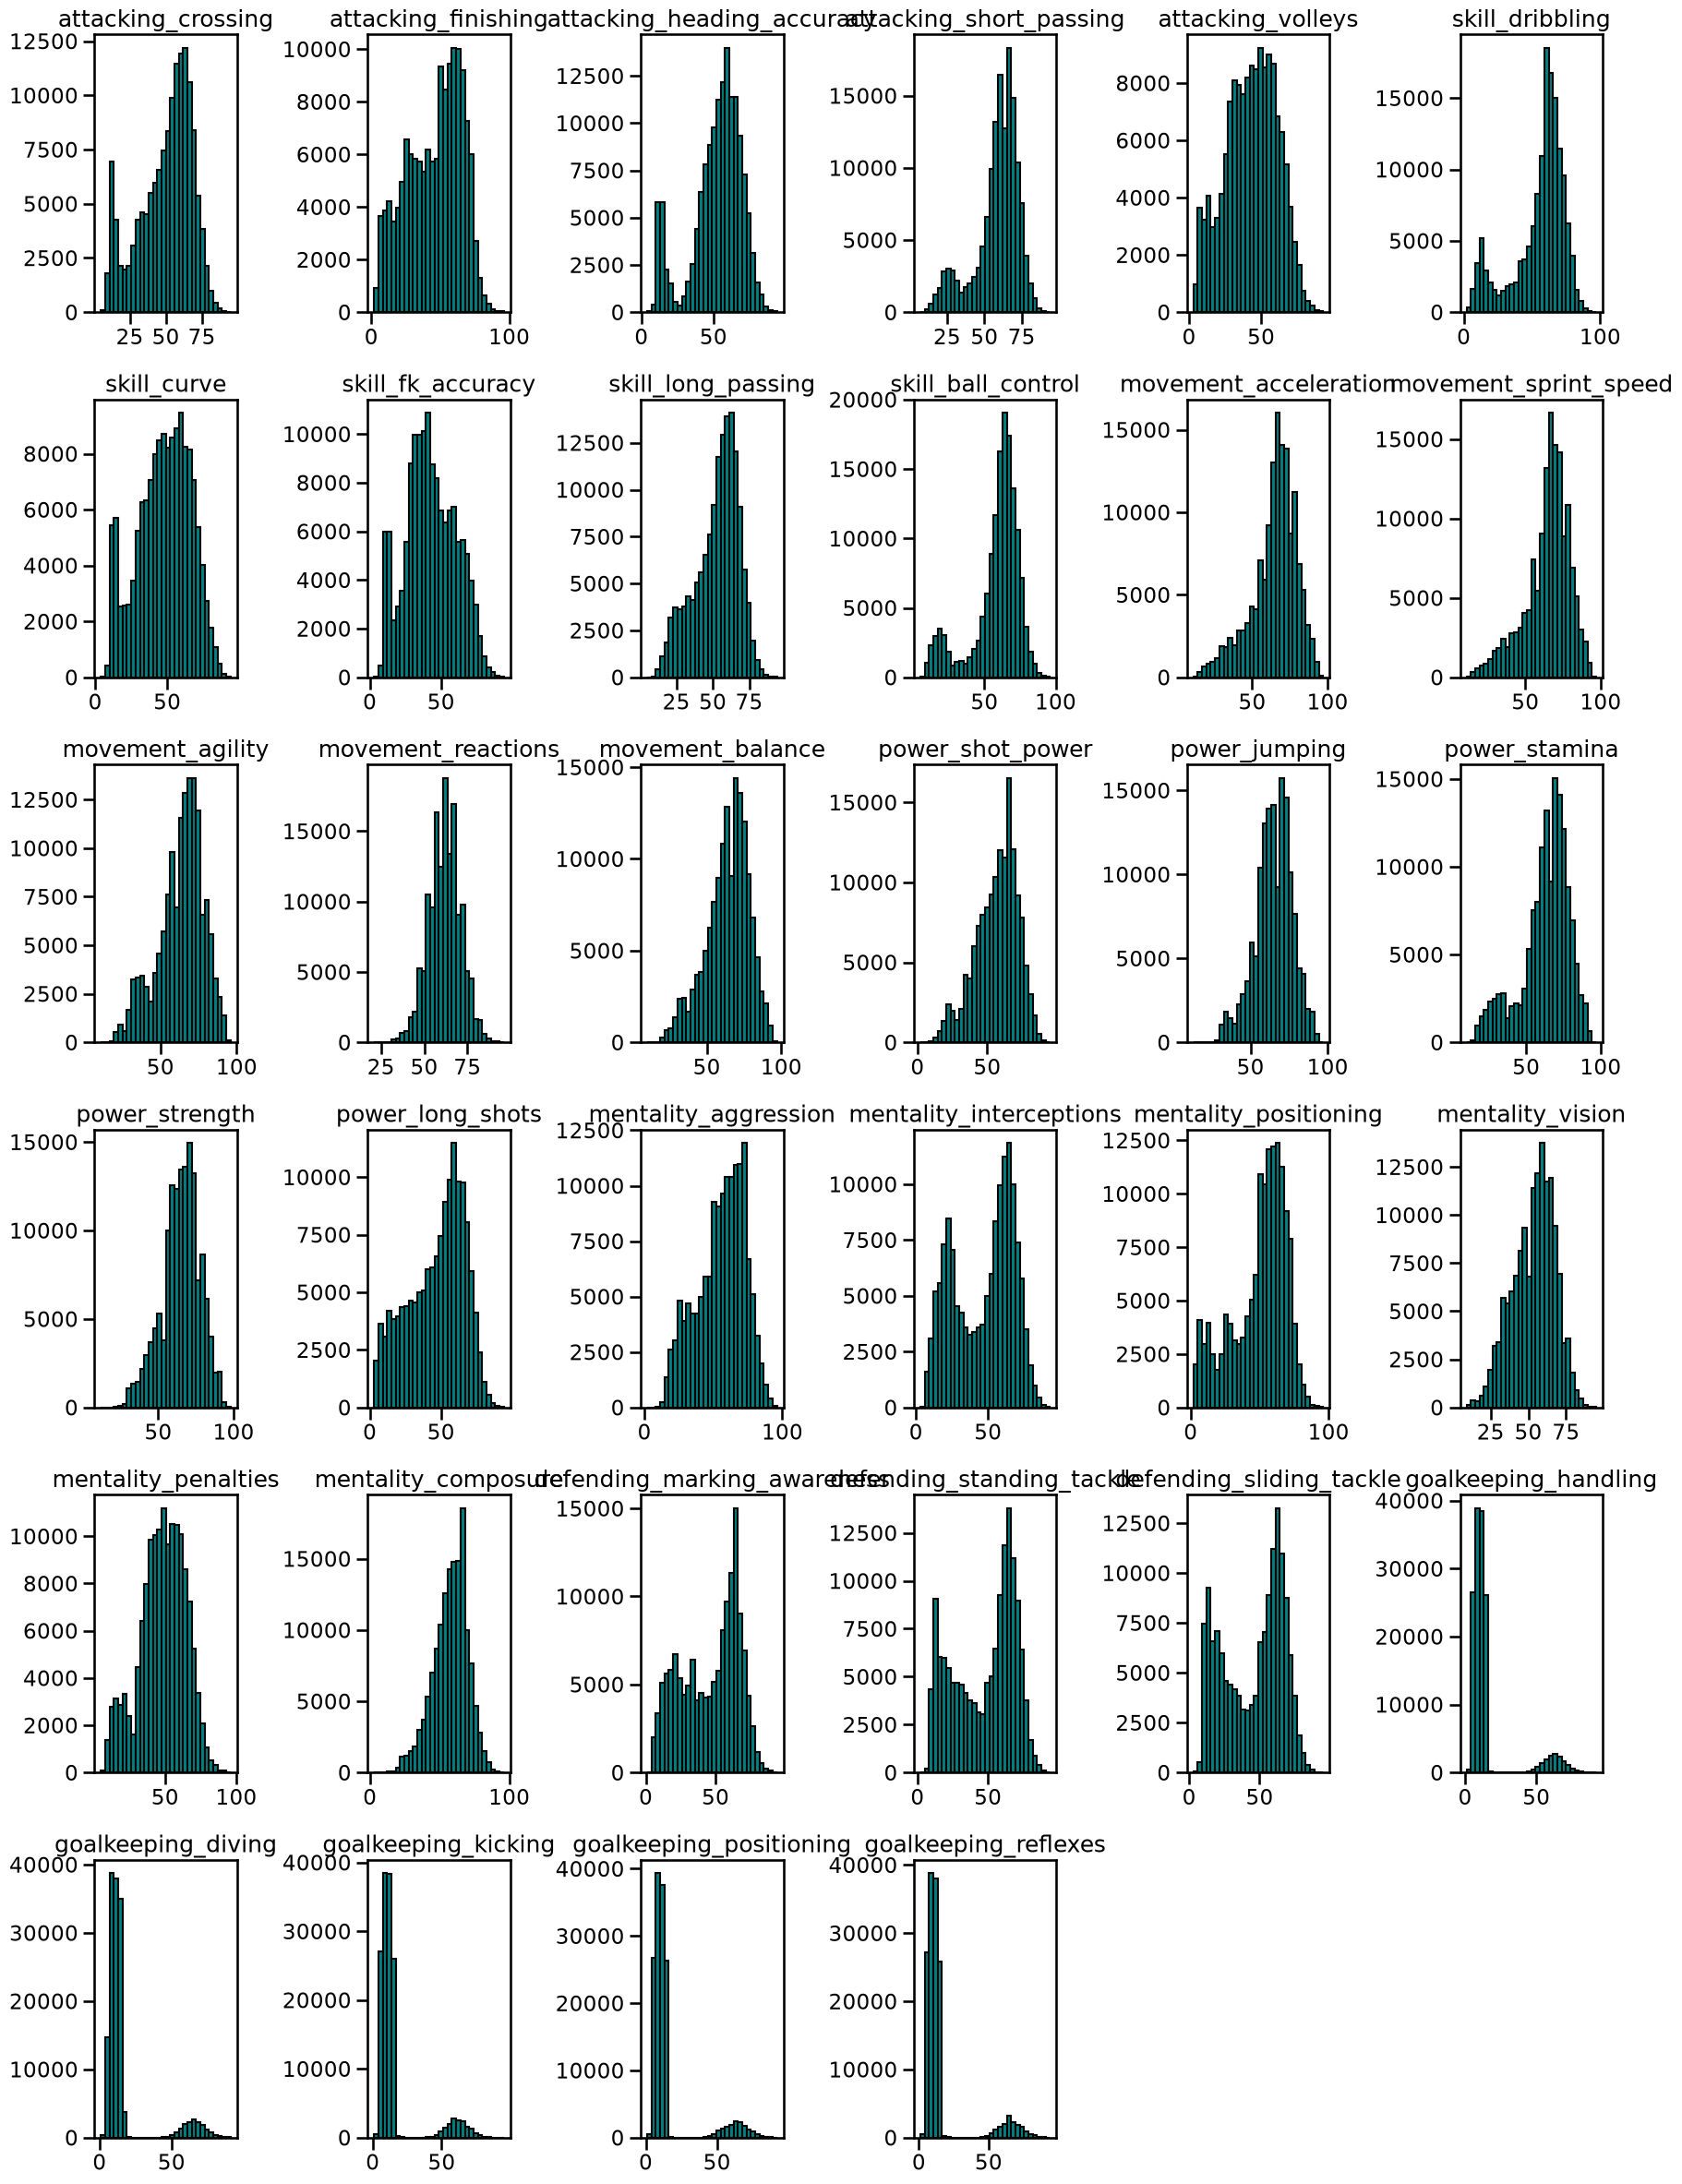

In [ ]:
# Histogramas para las variables de skill
df_skills.hist(figsize=(18, 24), bins=30, color='teal', edgecolor='black', grid=False)
plt.tight_layout()
plt.show()

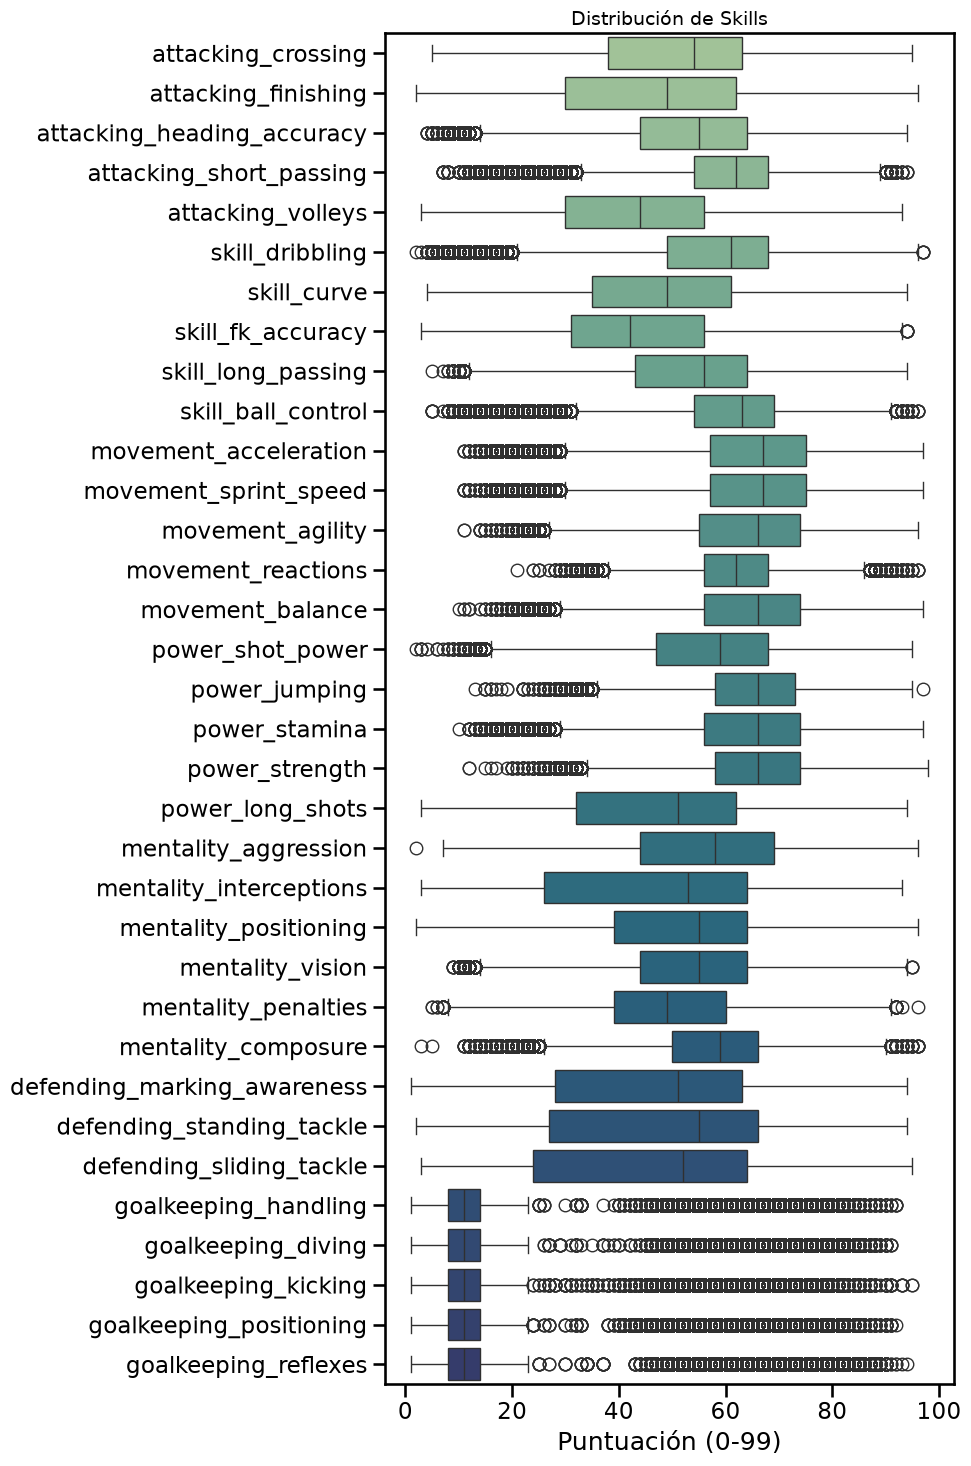

In [ ]:
# Visualizacion en boxplot de las skills
plt.figure(figsize=(10, 15))

sns.boxplot(data=df_skills, orient="h", palette="crest")

plt.title("Distribución de Skills", fontsize=14)
plt.xlabel("Puntuación (0-99)")
plt.tight_layout()
plt.show()

In [ ]:
data_filtered['principal_position'] = data_filtered['player_positions'].str.split(',').str[0].str.strip()

# Diccionario de mapeo
pos_map = {
    **{p: 'Forward' for p in forwards},
    **{p: 'Midfielder' for p in midfielders},
    **{p: 'Defender' for p in defenders},
    **{p: 'GK' for p in goalkeepers}
}

# Aplicar el mapeo directamente
data_filtered['position'] = data_filtered['principal_position'].map(pos_map).fillna('nan')
data_filtered['position'].value_counts()

position
Midfielder    54365
Defender      48401
Forward       27945
GK            16422
Name: count, dtype: int64

In [ ]:
categorical_cols = ['nationality_name','preferred_foot','weak_foot','skill_moves',
                   'work_rate','body_type','position']

def graficar_categoricas(df, cat_cols, top_n=10):
    n = len(cat_cols)
    if n == 0:
        return

    fig, axes = plt.subplots(n, 1, figsize=(10, 4 * n))
    if n == 1:
        axes = [axes]

    for i, col in enumerate(cat_cols):
        # astype(str) homogeneiza números y texto. sort_values pone la barra más alta arriba.
        counts = (
            df[col]
            .astype(str)
            .value_counts(dropna=False)
            .head(top_n)
            .sort_values(ascending=True)
        )

        counts.plot(kind="barh", ax=axes[i], color="#4C72B0", edgecolor="black")
        axes[i].set_title(f"Distribución: {col}", fontweight="bold")
        axes[i].set_xlabel("Conteo")
        axes[i].grid(axis="x", linestyle="--", alpha=0.7)

    plt.tight_layout()
    plt.show()

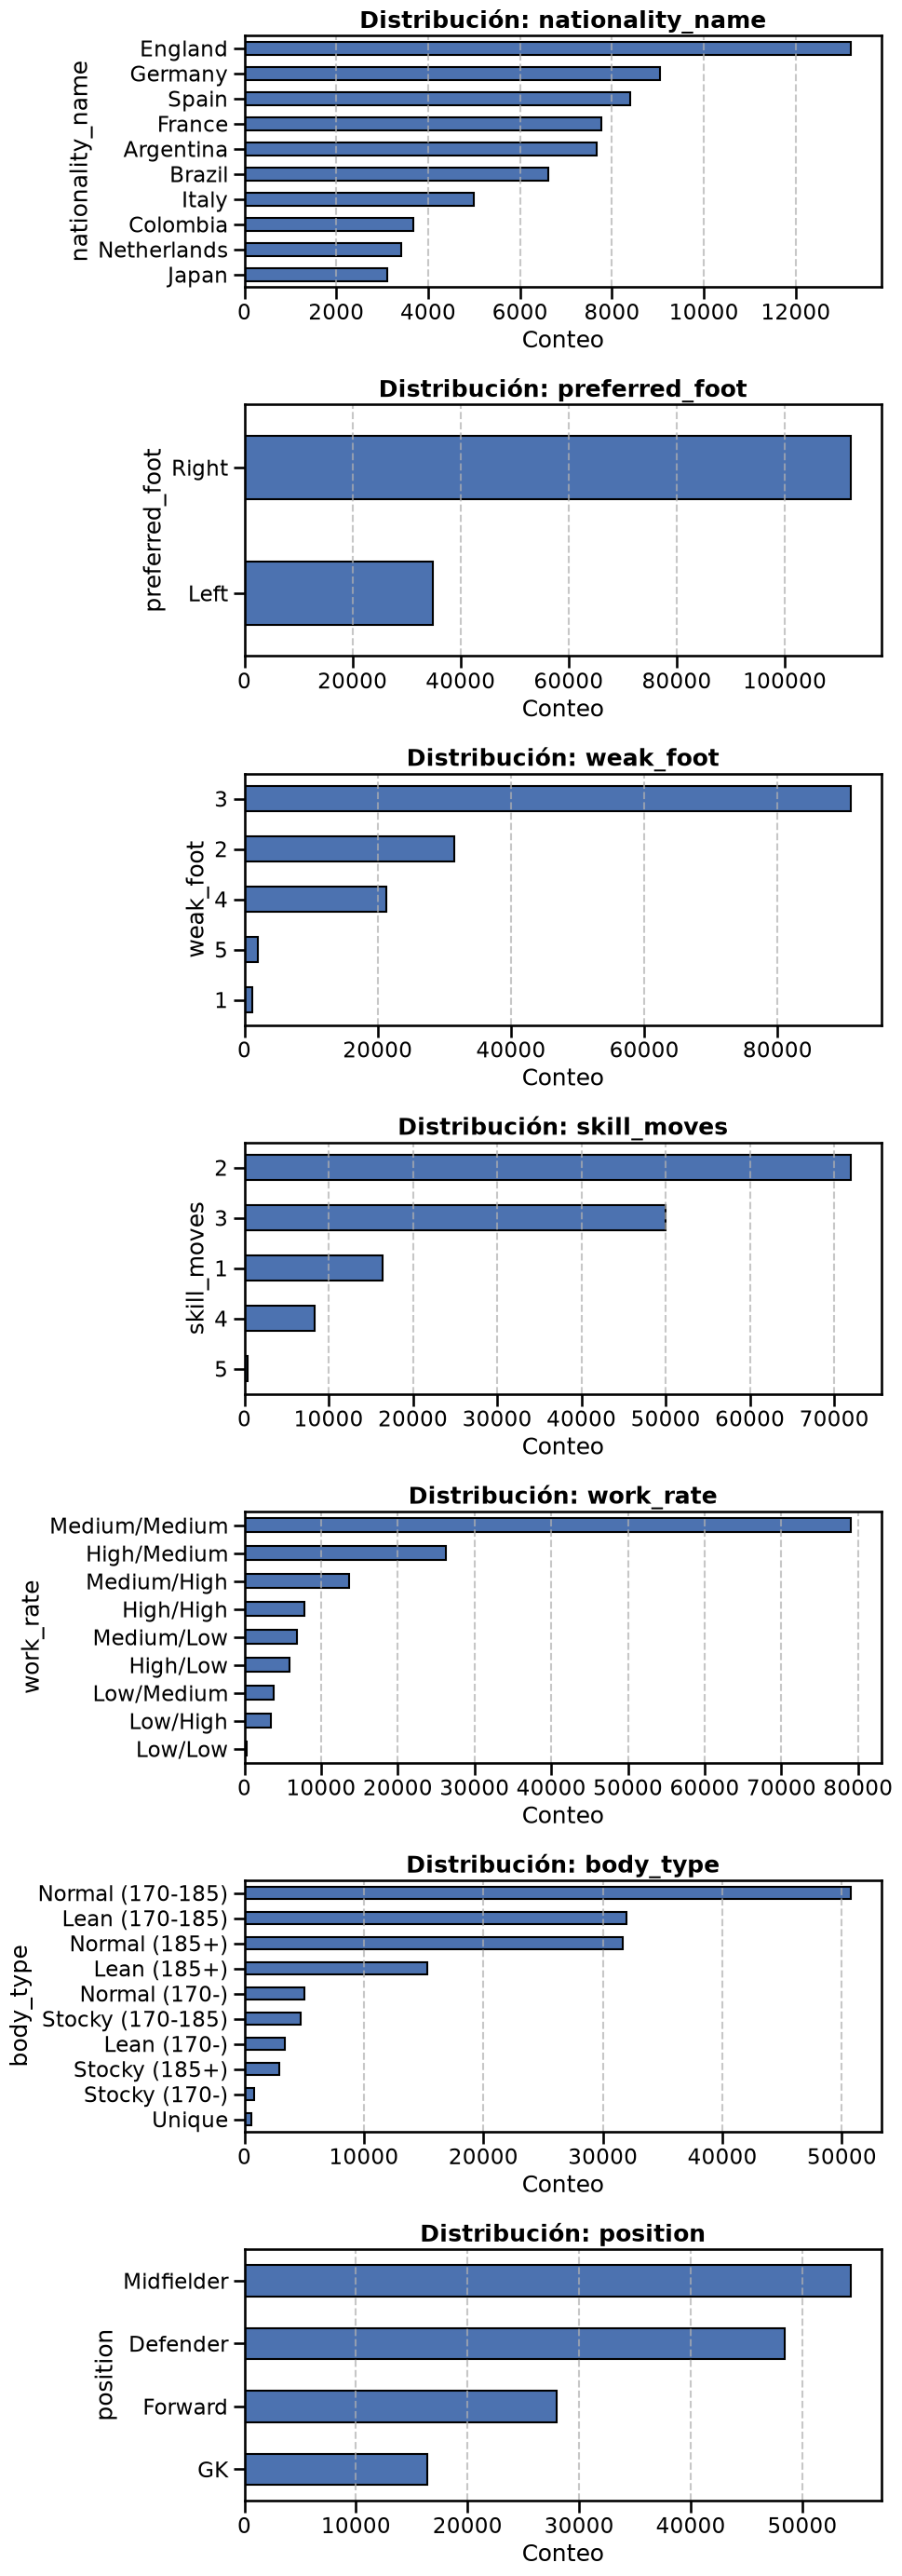

In [ ]:
graficar_categoricas(data_filtered, categorical_cols, top_n=10)

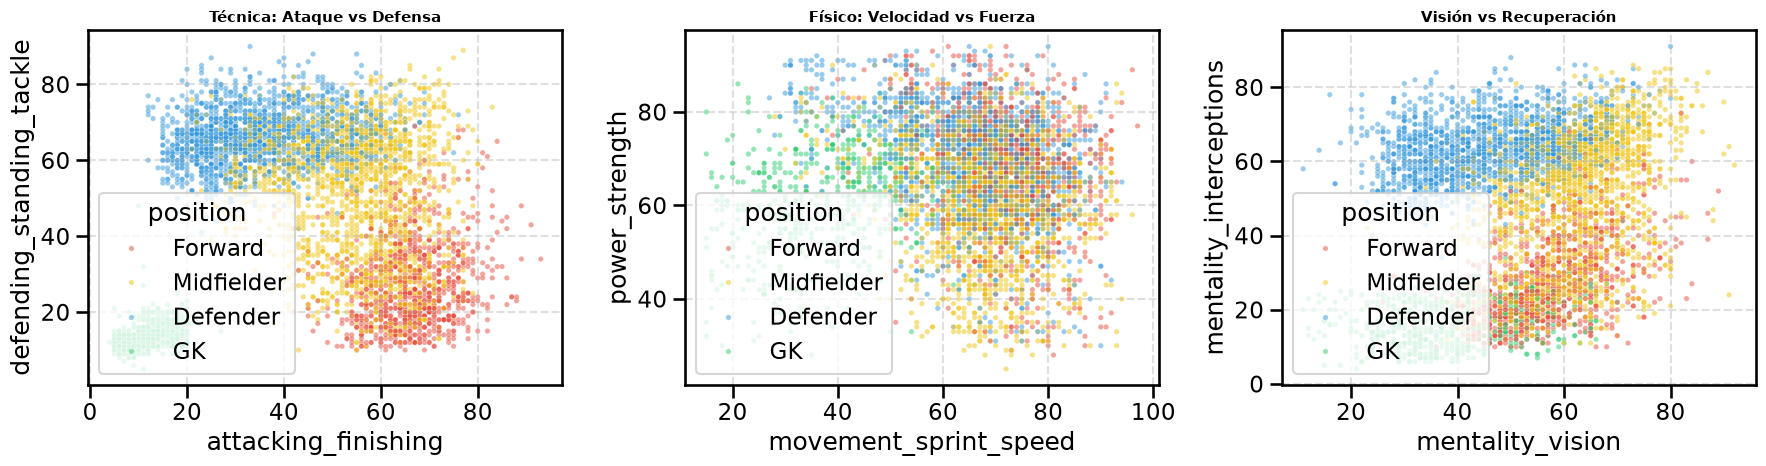

In [ ]:
# 1. Parámetros de la muestra y colores para acelerar el renderizado
df_sample = data_filtered.sample(n=5000, random_state=42)
paleta_pos = {
    'Forward': '#e74c3c',
    'Midfielder': '#f1c40f',
    'Defender': '#3498db',
    'GK': '#2ecc71',
}

# 2. Definición de pares de variables con sentido intuitivo
pares_estrategicos = [
    (
        'attacking_finishing',
        'defending_standing_tackle',
        'Técnica: Ataque vs Defensa',
    ),
    (
        'movement_sprint_speed',
        'power_strength',
        'Físico: Velocidad vs Fuerza',
    ),
    (
        'mentality_vision',
        'mentality_interceptions',
        'Visión vs Recuperación',
    ),
]

# 3. Renderizado de gráficos 2 a 2
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (var_x, var_y, titulo) in enumerate(pares_estrategicos):
    sns.scatterplot(
        data=df_sample,
        x=var_x,
        y=var_y,
        hue='position',
        palette=paleta_pos,
        alpha=0.5,
        s=15,
        ax=axes[i],
    )
    axes[i].set_title(f'{titulo}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(var_x)
    axes[i].set_ylabel(var_y)
    axes[i].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [ ]:
data_temp = data_sample.loc[:,["position",'attacking_finishing','defending_sliding_tackle','mentality_interceptions']]
sns.pairplot(data_sample, hue="position",palette='bright')